# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import collections
import itertools
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import torch
from nettcr.models import NetTCR
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
with h5py.File('data/processed/sequences_pMHC_split.h5') as fh:
    cdr1_alphas = fh['cdr1_alpha'][:]
    cdr2_alphas = fh['cdr2_alpha'][:]
    cdr3_alphas = fh['cdr3_alpha'][:]
    cdr1_betas = fh['cdr1_beta'][:]
    cdr2_betas = fh['cdr2_beta'][:]
    cdr3_betas = fh['cdr3_beta'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    for model_path in 'models/TCRStructMap', 'models/TCRStructMap_sequence_only':
        print('Loading model:', model_path)
        model = TCRStructMap()
        model.load_state_dict(
            torch.load(
                os.path.join(model_path, f'model_{fold_num}.pt'),
                map_location=torch.device('cpu'),
                weights_only=True,
            )
        )

        print('Making predictions')
        model.eval()

        prediction = model(
            torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
            torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
        )

        model_name = os.path.basename(model_path)

        predictions.append(
            pd.DataFrame(
                {
                    'index': hold_out_indicies,
                    'fold': [fold_num for _ in range(len(hold_out_indicies))],
                    'model_name': [model_name for _ in range(len(hold_out_indicies))],
                    'label': labels[hold_out_indicies],
                    'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
                }
            )
        )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 2
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 3
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 4
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 5
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions


In [4]:
with h5py.File('data/processed/sequences_right_pad_blosum.h5') as fh:
    cdr1_alphas_nettcr = fh['cdr1_alpha'][:]
    cdr2_alphas_nettcr = fh['cdr2_alpha'][:]
    cdr3_alphas_nettcr = fh['cdr3_alpha'][:]
    cdr1_betas_nettcr = fh['cdr1_beta'][:]
    cdr2_betas_nettcr = fh['cdr2_beta'][:]
    cdr3_betas_nettcr = fh['cdr3_beta'][:]
    peptides_nettcr = fh['peptide'][:]

    folds_nettcr = fh['fold'][:]
    labels_nettcr = fh['label'][:]

In [5]:
predictions_nettcr = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds_nettcr == fold_num)[0]

    model = NetTCR()
    model.load_state_dict(
        torch.load(
            os.path.join('models/NetTCR', f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(peptides_nettcr[hold_out_indicies], dtype=torch.float32),
    )

    predictions_nettcr.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['NetTCR' for _ in range(len(hold_out_indicies))],
                'label': labels_nettcr[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

predictions_nettcr = pd.concat(predictions_nettcr)

Fold: 1
Making predictions
Fold: 2
Making predictions
Fold: 3
Making predictions
Fold: 4
Making predictions
Fold: 5
Making predictions


In [6]:
predictions = pd.concat([predictions, predictions_nettcr])

In [7]:
def model_name_sort_key(name: str) -> tuple[str, str]:
    return (-ord(name[0]), name)

## Model Size

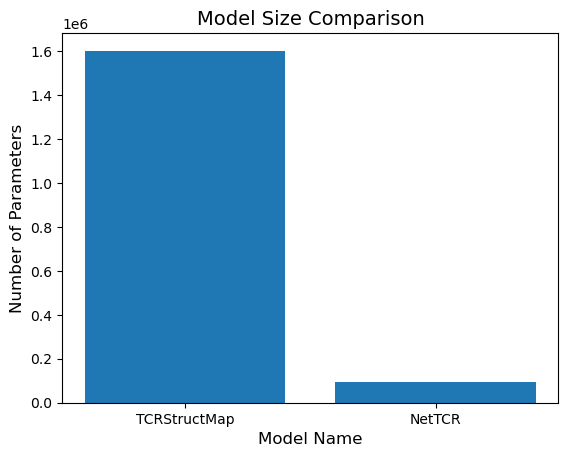

In [8]:
def count_parameters(model: torch.nn.Module) -> int:
    """Count the number of parmeters in a pytorch model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


plt.bar(x=['TCRStructMap', 'NetTCR'], height=[count_parameters(model) for model in (TCRStructMap(), NetTCR())])

plt.title('Model Size Comparison', fontsize=14)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)

plt.show()

## ROC

In [9]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [10]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [11]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

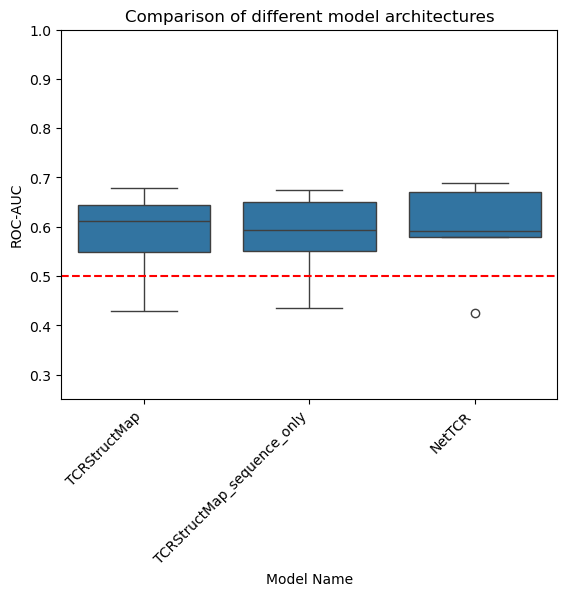

,mean,median,std
model_name,,,
TCRStructMap,0.582115,0.612001,0.098665
TCRStructMap_sequence_only,0.581122,0.593776,0.095046
NetTCR,0.591561,0.591135,0.104491


In [12]:
plt.title('Comparison of different model architectures')

sns.boxplot(
    roc_results,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

roc_results_agg = roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_agg = roc_results_agg.loc[sorted(roc_results_agg.index, key=model_name_sort_key)]

roc_results_agg

In [13]:
pg.friedman(roc_results, dv='roc_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.04,1.6,6.4,0.166667,0.805424


In [14]:
groups = list(roc_results.set_index('fold').groupby('model_name')['roc_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,7.0,0.59375,False
1,TCRStructMap,NetTCR,7.0,0.59375,False
2,TCRStructMap_sequence_only,NetTCR,6.0,0.68750,False


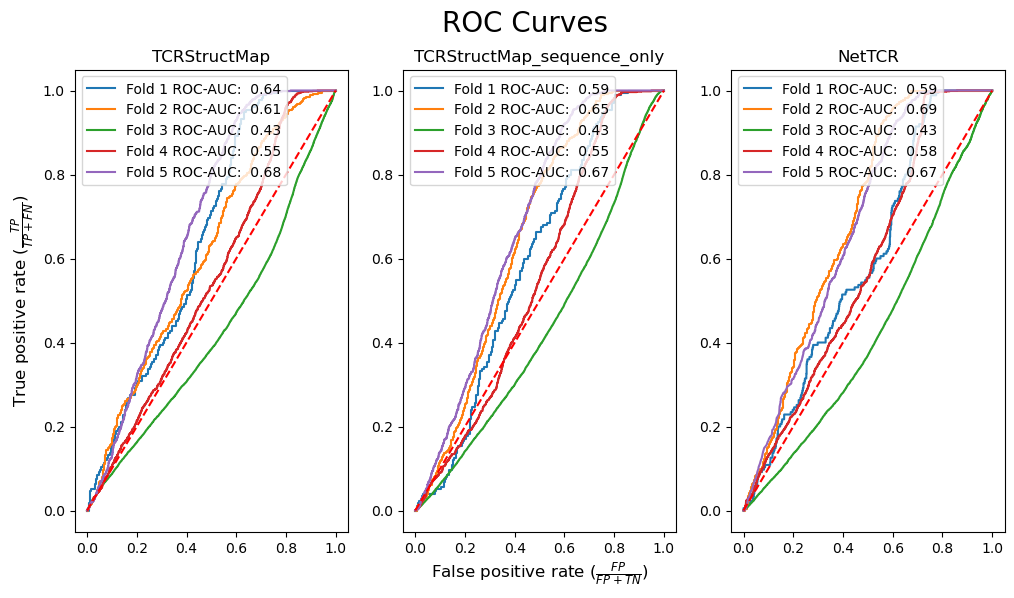

In [15]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [16]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

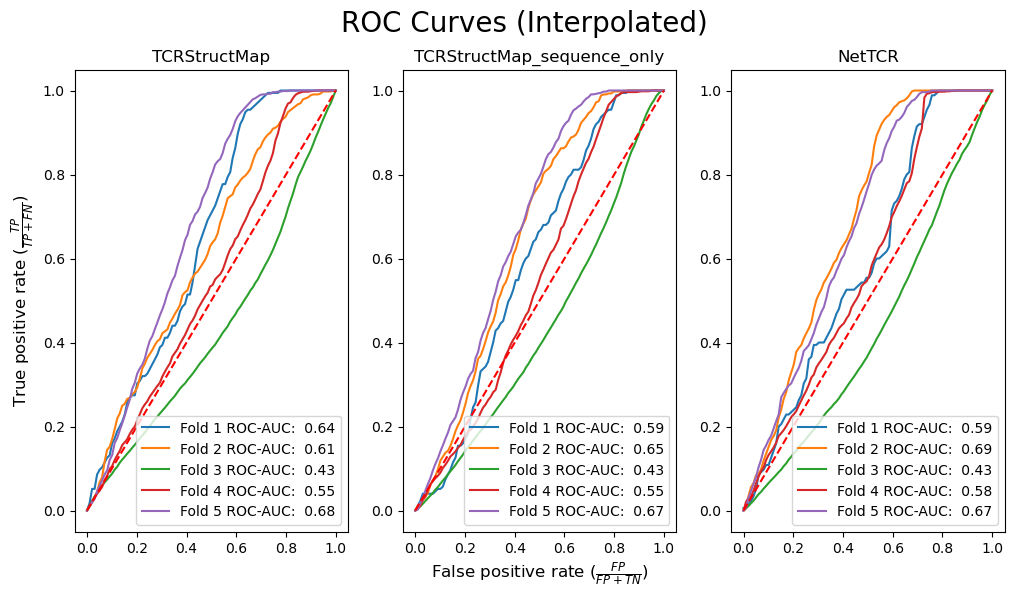

In [17]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

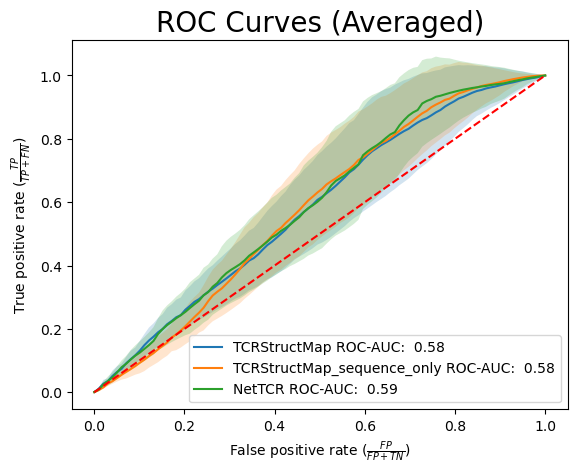

In [18]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [19]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [20]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [21]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

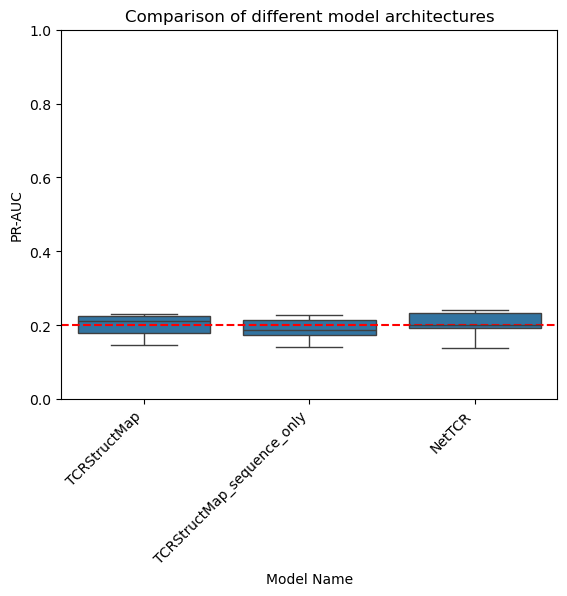

,mean,median,std
model_name,,,
TCRStructMap,0.199082,0.212683,0.035602
TCRStructMap_sequence_only,0.188626,0.187824,0.034040
NetTCR,0.201483,0.199862,0.040667


In [22]:
sns.boxplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], key=model_name_sort_key))
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

pr_results_agg = pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_agg = pr_results_agg.loc[sorted(pr_results_agg.index, key=model_name_sort_key)]
pr_results_agg

In [23]:
pg.friedman(pr_results, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.28,1.6,6.4,1.555556,0.274932


In [24]:
groups = list(pr_results.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,14.0,0.06250,False
1,TCRStructMap,NetTCR,6.0,0.68750,False
2,TCRStructMap_sequence_only,NetTCR,1.0,0.96875,False


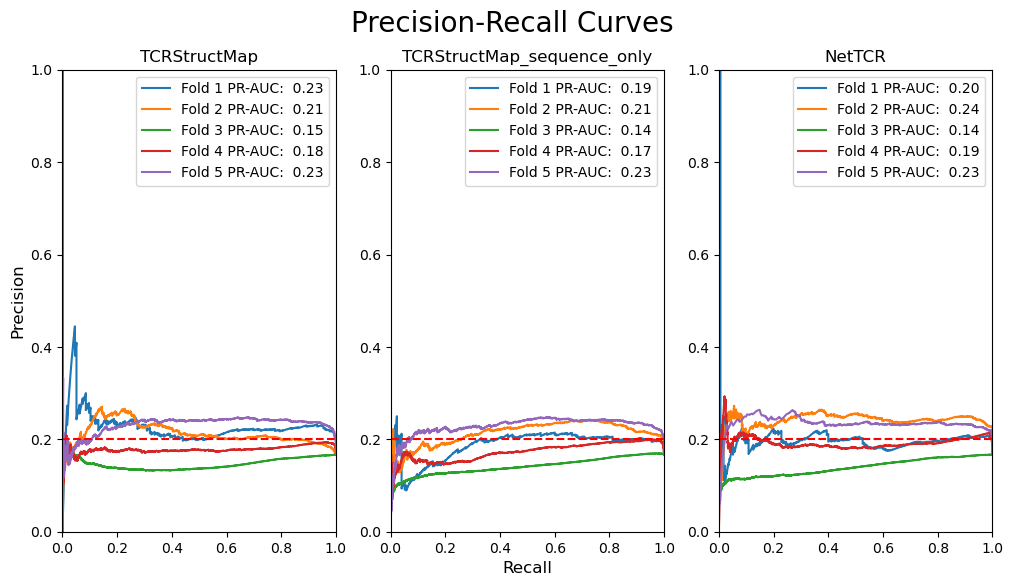

In [25]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [26]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

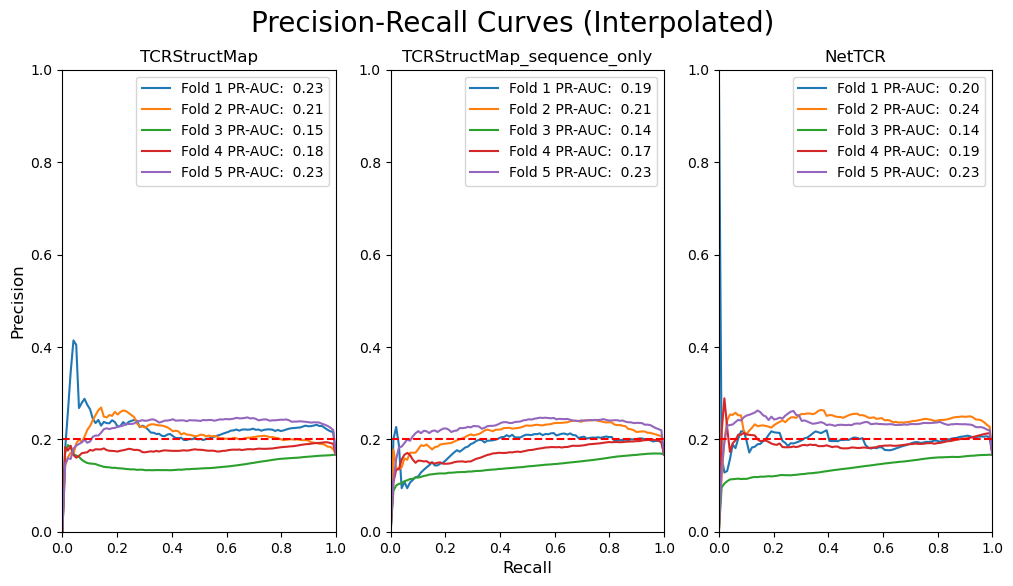

In [27]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

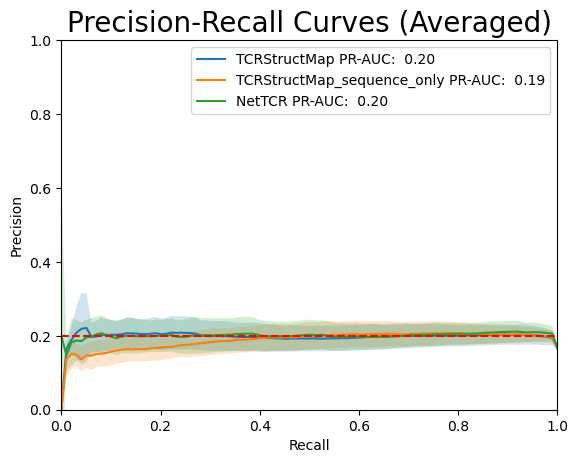

In [28]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [29]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [30]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [31]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [32]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

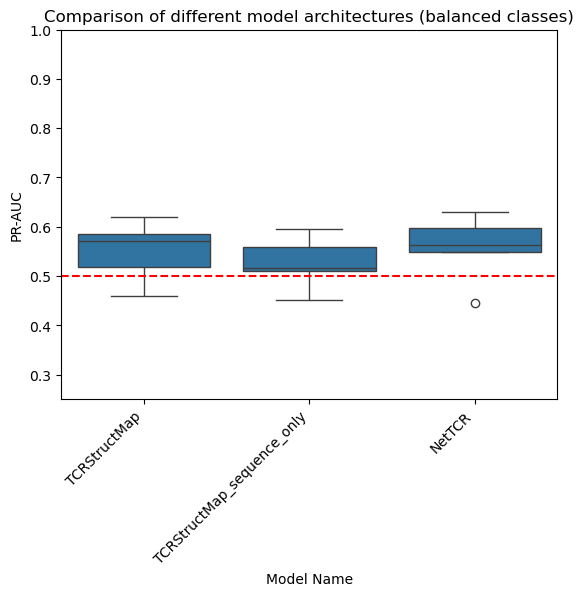

,mean,median,std
model_name,,,
TCRStructMap,0.550823,0.571186,0.063164
TCRStructMap_sequence_only,0.526516,0.516956,0.054179
NetTCR,0.556616,0.563779,0.069713


In [33]:
sns.boxplot(
    pr_results_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_balanced['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

pr_results_balanced_agg = pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_balanced_agg = pr_results_balanced_agg.loc[sorted(pr_results_balanced_agg.index, key=model_name_sort_key)]
pr_results_balanced_agg

In [34]:
pg.friedman(pr_results_balanced, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.28,1.6,6.4,1.555556,0.274932


In [35]:
groups = list(pr_results_balanced.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,12.0,0.15625,False
1,TCRStructMap,NetTCR,6.0,0.68750,False
2,TCRStructMap_sequence_only,NetTCR,2.0,0.93750,False


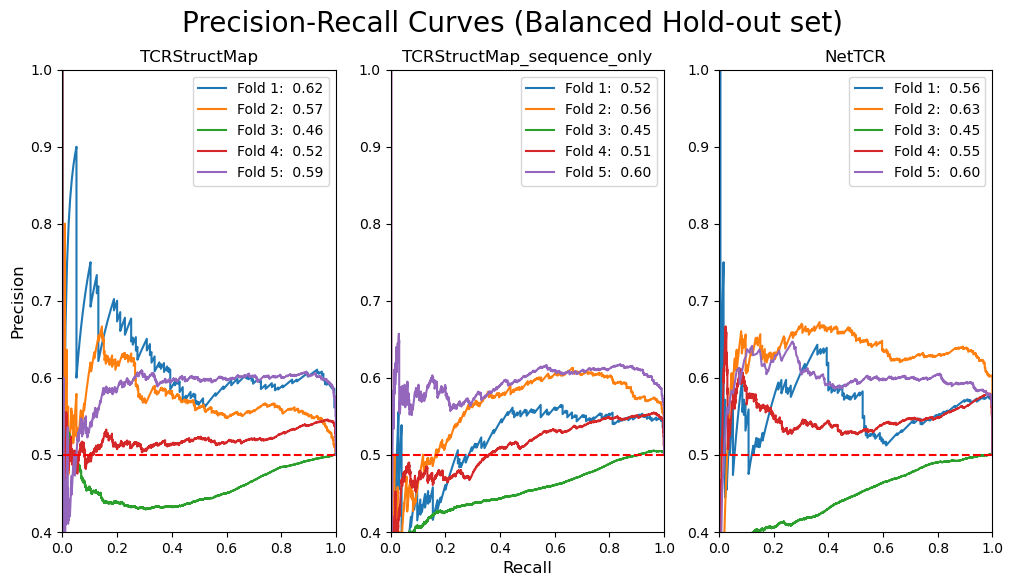

In [36]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [37]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

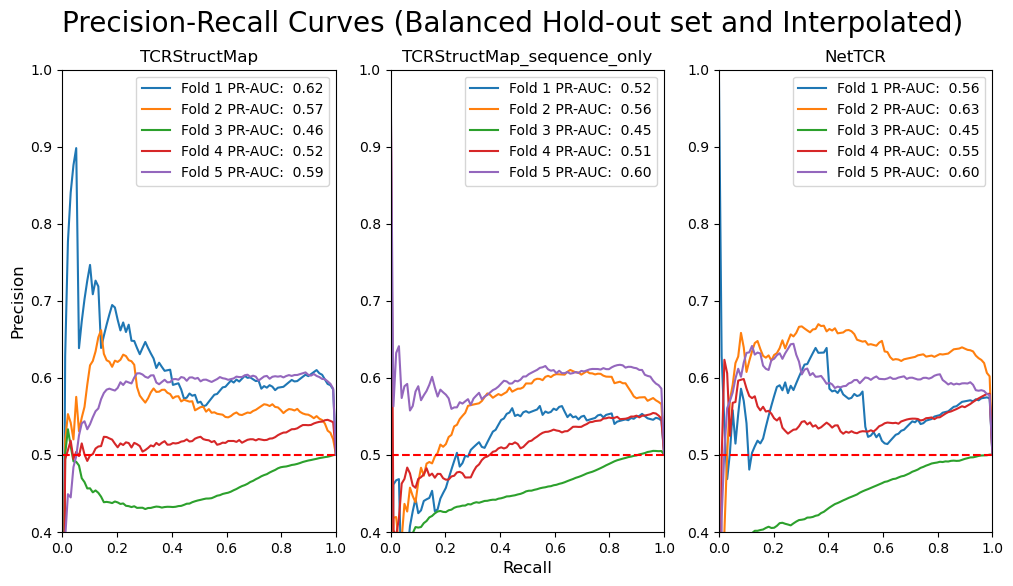

In [38]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

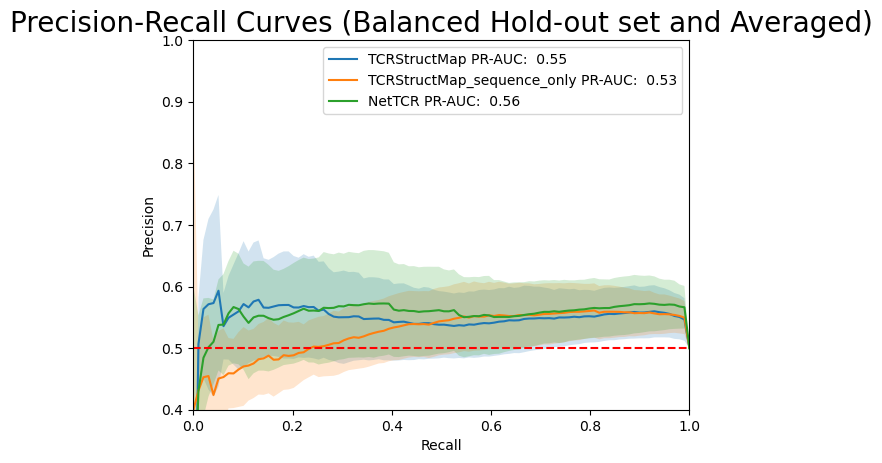

In [39]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [40]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [41]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results_table = f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, key=model_name_sort_key)]
f1_results_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.166667,0.072464,0.0
2,0.190337,0.162025,0.0
3,0.126461,0.092590,0.0
4,0.097100,0.098013,0.0
5,0.149454,0.158025,0.0


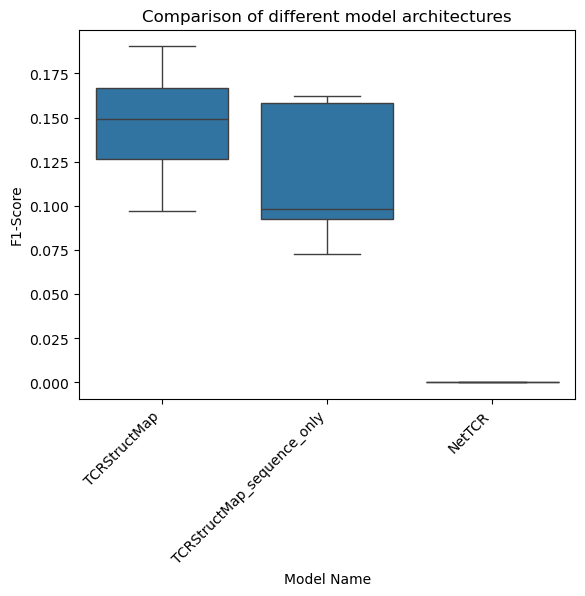

,mean,median,std
model_name,,,
TCRStructMap,0.146004,0.149454,0.035978
TCRStructMap_sequence_only,0.116623,0.098013,0.040772
NetTCR,0.000000,0.000000,0.000000


In [42]:
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_agg = f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_agg = f1_results_agg.loc[sorted(f1_results_agg.index, key=model_name_sort_key)]
f1_results_agg

In [43]:
pg.friedman(f1_results, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.76,1.6,6.4,12.666667,0.007191


In [44]:
groups = list(f1_results.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,12.0,0.15625,False
1,TCRStructMap,NetTCR,15.0,0.03125,False
2,TCRStructMap_sequence_only,NetTCR,15.0,0.03125,False


### Balancing classes

In [45]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [46]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced_table = f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_balanced_table = f1_results_balanced_table[
    sorted(f1_results_balanced_table.columns, key=model_name_sort_key)
]
f1_results_balanced_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.220096,0.099010,0.0
2,0.245747,0.228980,0.0
3,0.177929,0.129895,0.0
4,0.119502,0.121311,0.0
5,0.192017,0.205788,0.0


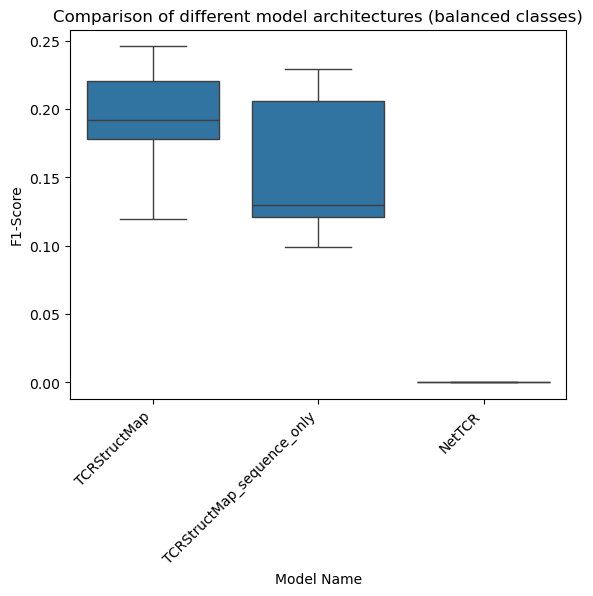

,mean,median,std
model_name,,,
TCRStructMap,0.191058,0.192017,0.047769
TCRStructMap_sequence_only,0.156997,0.129895,0.056861
NetTCR,0.000000,0.000000,0.000000


In [47]:
sns.boxplot(
    f1_results_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_balanced['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_balanced_agg = f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_balanced_agg = f1_results_balanced_agg.loc[sorted(f1_results_balanced_agg.index, key=model_name_sort_key)]
f1_results_balanced_agg

In [48]:
pg.friedman(f1_results_balanced, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.76,1.6,6.4,12.666667,0.007191


In [49]:
groups = list(f1_results_balanced.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,12.0,0.15625,False
1,TCRStructMap,NetTCR,15.0,0.03125,False
2,TCRStructMap_sequence_only,NetTCR,15.0,0.03125,False


## Comparison of prediction results to mimimum distance between the peptides and the training set

In [50]:
sequences = pd.read_csv('data/interim/sequences_pMHC_split.csv', index_col='index')

In [51]:
predictions = predictions.merge(sequences[['peptide']], how='left', left_on='index', right_index=True)

In [52]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [53]:
def get_minimum_peptide_distance(peptide_sequence: str, training_peptides: np.ndarray) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [54]:
peptide_folds = predictions[['peptide', 'fold', 'model_name']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(
        row.peptide,
        sequences[sequences['fold'] != row.fold]['peptide'].unique(),
    ),
    axis=1,
)

In [55]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide', 'fold', 'model_name'])

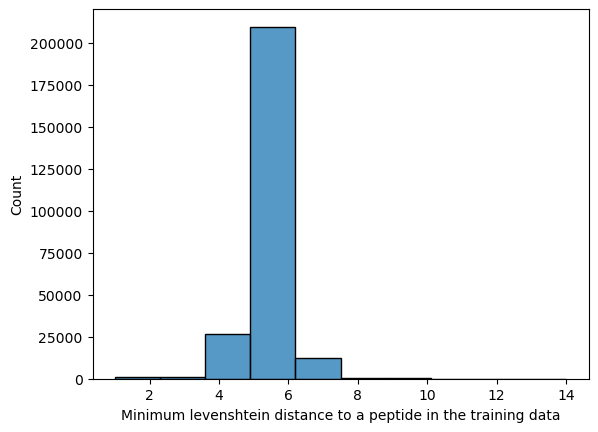

In [56]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

In [57]:
peptide_distance_roc_aucs = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
peptide_distance_roc_aucs.name = 'roc_auc'

peptide_distance_roc_aucs = peptide_distance_roc_aucs.reset_index()

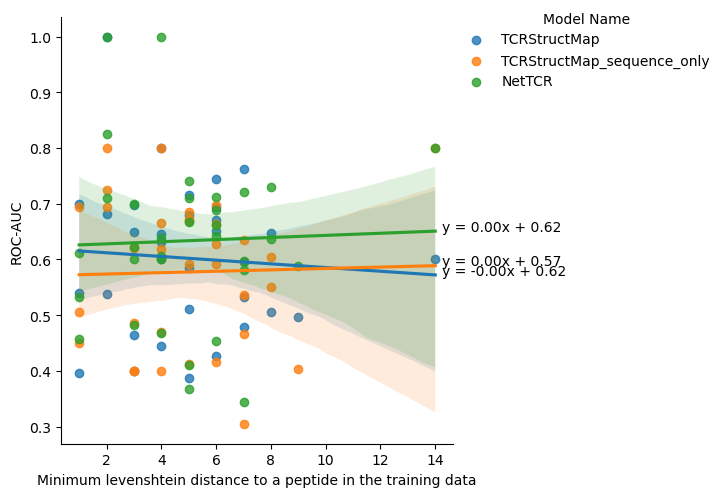

In [58]:
ax = sns.lmplot(
    peptide_distance_roc_aucs,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs['model_name'].unique(), key=model_name_sort_key),
)

for model_name in peptide_distance_roc_aucs['model_name'].unique():
    subset = peptide_distance_roc_aucs[peptide_distance_roc_aucs['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
ax.legend.set_loc('upper right')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [59]:
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_lines.name = 'line'
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs_lines.reset_index()

peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

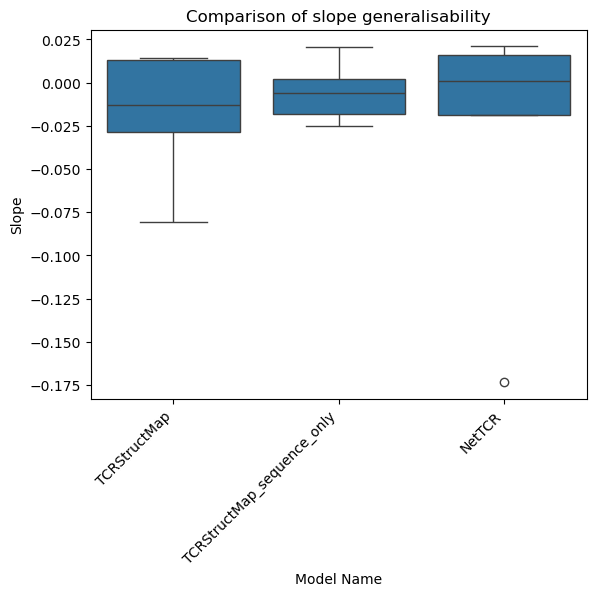

,mean,median,std
model_name,,,
TCRStructMap,-0.018875,-0.012713,0.038882
TCRStructMap_sequence_only,-0.005348,-0.006165,0.018017
NetTCR,-0.030904,0.000979,0.081186


In [60]:
sns.boxplot(
    peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_lines_agg.index, key=model_name_sort_key)
]
peptide_distance_roc_aucs_lines_agg

In [61]:
pg.friedman(peptide_distance_roc_aucs_lines, dv='slope', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.28,1.6,6.4,1.555556,0.274932


In [62]:
groups = list(peptide_distance_roc_aucs_lines.set_index('fold').groupby('model_name')['slope'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,4.0,0.84375,False
1,TCRStructMap,NetTCR,8.0,0.50000,False
2,TCRStructMap_sequence_only,NetTCR,11.0,0.21875,False
